# Static Accuracy Analysis (thesis-grade)

Loads the most recent `static_accuracy` run and reports static accuracy in the Y-Z plane (Volcaniarm is 2-DOF planar; X is fixed bias).

**Headline metric**: `d_error = d_detected - d_urdf`, signed. Each is the Y-Z origin-to-origin distance computed in the **world frame**:
- `d_detected = ||(apriltag_marker_ee.origin - apriltag_marker_base.origin)_yz||` in `world`
- `d_urdf     = ||(apriltag_ee_link.origin   - apriltag_base_link.origin)_yz||`   in `world`

Both origins are looked up in a single common world-aligned frame before the difference is taken, so Y and Z refer to the same physical axes for detection and URDF (the apriltag marker frames have different parent orientations than the URDF tag links — comparing their parent-frame components directly is wrong).

The runner logs `det_base_y/z`, `det_ee_y/z`, `urdf_base_y/z`, `urdf_ee_y/z`, plus `d_detected`, `d_urdf`, `d_error` directly into `tag_observations.csv` at capture time. **Repeatability** (`RP_yz`, ISO 9283) is the cluster scatter of `det_ee_y/z` (world frame). **Application zones**: `acceptable <= 10 mm`, `marginal 10-30 mm`, `failing > 30 mm` (tunable in `analysis/metrics.py`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from volcaniarm_calibration.analysis import (
    accuracy_segment_length, align_fk_to_tag, latest_run, list_runs, load_run,
    repeatability_iso9283, summary, threshold_color, threshold_zone,
    WEEDING_ACCEPTABLE_MM, WEEDING_MARGINAL_MM,
)

TEST_NAME = 'static_accuracy'
RUN_DIR = latest_run(TEST_NAME)
run = load_run(RUN_DIR)
config, tag, fk = run['config'], run['tag'], run['fk']
print(f'run_id:       {config.get("run_id")}')
print(f'status:       {config.get("status")}  failure_reason: {config.get("failure_reason")}')
print(f'goal (y, z):  {config["goals"][0]}')
print(f'iterations:   {config["num_cycles"]}')
print(f'tag rows:     {len(tag)}')
print(f'fk rows:      {len(fk)}')

target = tag[tag['phase'] == 'target'].copy()
home = tag[tag['phase'] == 'home'].copy()

run_id:       static_accuracy/2026-05-07/14-59-26
status:       completed  failure_reason: None
goal (y, z):  [0.25, 0.7]
iterations:   3
tag rows:     4
fk rows:      3


## Repeatability (RP_yz, ISO 9283) on world-frame EE origin

Distance of each detected EE marker origin from the cluster centroid, all in the world frame. Frame-independent in practice for repeatability — the cluster geometry rotates with the data, so RP is unaffected by which world-aligned frame we use.

In [2]:
rep = repeatability_iso9283(target, dims=('det_ee_y', 'det_ee_z'))
print(f'n samples:      {rep["n"]}')
print(f'centroid (y,z): ({rep["centroid"][0]:.4f}, {rep["centroid"][1]:.4f}) m  (world)')
print(f'per-dim std:    y={rep["per_dim_std"][0]*1000:.3f} mm, '
      f'z={rep["per_dim_std"][1]*1000:.3f} mm')
if rep['n'] >= 2:
    s = summary(rep['d_to_centroid'])
    print(f'\ndistance-to-centroid: {s.in_mm()}')
    print(f'\nRP_yz (ISO 9283):  {rep["RP_m"]*1000:.3f} mm   '
          f'(zone: {threshold_zone(rep["RP_m"]*1000)})')
    print(f'worst (max d_to_centroid): {rep["worst_m"]*1000:.3f} mm   '
          f'(zone: {threshold_zone(rep["worst_m"]*1000)})')
else:
    print('\nNeed >= 2 samples for repeatability. Re-run with iterations >= 5.')

n samples:      3
centroid (y,z): (0.2283, 0.2334) m  (world)
per-dim std:    y=0.203 mm, z=0.693 mm

distance-to-centroid: n=3  mean=+499.349 mm  std=384.394 mm  worst=742.563 mm  95% CI ±434.983 mm  median=+699.291 mm

RP_yz (ISO 9283):  1.653 mm   (zone: acceptable)
worst (max d_to_centroid): 0.743 mm   (zone: acceptable)


## Accuracy: detected vs URDF Y-Z origin distance (world frame)

For each target visit the runner captures both:
- `d_detected = ||(apriltag_marker_ee.origin - apriltag_marker_base.origin)_yz||` in `world`
- `d_urdf     = ||(apriltag_ee_link.origin   - apriltag_base_link.origin)_yz||`   in `world`

Their difference, `d_error = d_detected - d_urdf`, is the static accuracy residual: how far the detected EE marker's distance-from-base disagrees with the URDF prediction at the same instant. Because both origins are looked up in the same world-aligned frame, the Y and Z components refer to the same physical axes for detection and URDF.

In [3]:
acc = accuracy_segment_length(tag)
print(f'd_error across {acc.n} target visits:')
print(f'  {acc.in_mm()}')
zone = threshold_zone(abs(acc.mean) * 1000)
print(f'  mean |d_error| zone: {zone}')

per_visit = target[['cycle', 'target_idx', 'd_detected', 'd_urdf', 'd_error']].copy()
per_visit[['d_detected_mm', 'd_urdf_mm', 'd_error_mm']] = (
    per_visit[['d_detected', 'd_urdf', 'd_error']] * 1000
)
print('\nper-visit:')
print(per_visit[['cycle', 'target_idx', 'd_detected_mm', 'd_urdf_mm', 'd_error_mm']]
      .to_string(index=False, float_format=lambda v: f'{v:8.3f}'))

d_error across 3 target visits:
  n=3  mean=+19444.727 mm  std=1004.691 mm  worst=20375.665 mm  95% CI ±1136.915 mm  median=+19578.775 mm
  mean |d_error| zone: marginal

per-visit:
 cycle  target_idx  d_detected_mm  d_urdf_mm  d_error_mm
     1       1.000        806.036    787.656      18.380
     2       1.000        807.235    787.656      19.579
     3       1.000        808.032    787.656      20.376


## Distribution of `d_error` across visits

Histogram of the per-visit accuracy residual, with the application threshold lines for context. Centred close to zero = the URDF mount values agree with the detected geometry. A consistent offset = bias in the URDF tag mounts that should be calibrated into the xacro.

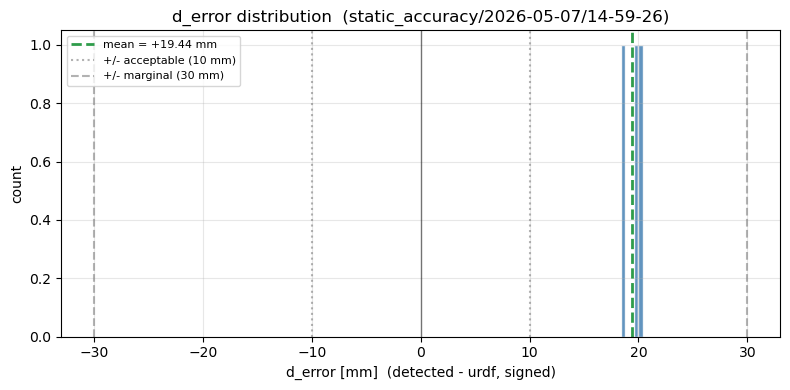

In [4]:
d_err_mm = (target['d_error'].dropna().to_numpy() * 1000)
if d_err_mm.size == 0:
    print('no d_error rows in this run.')
else:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.hist(d_err_mm, bins=max(5, len(d_err_mm) // 2),
            color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0.0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(d_err_mm.mean(), color='#2e9c4a', linestyle='--', linewidth=2,
               label=f'mean = {d_err_mm.mean():+.2f} mm')
    for lim_mm, style, lbl in (
        (WEEDING_ACCEPTABLE_MM, ':', f'+/- acceptable ({WEEDING_ACCEPTABLE_MM:.0f} mm)'),
        (WEEDING_MARGINAL_MM, '--', f'+/- marginal ({WEEDING_MARGINAL_MM:.0f} mm)'),
    ):
        ax.axvline(+lim_mm, color='gray', linestyle=style, alpha=0.6, label=lbl)
        ax.axvline(-lim_mm, color='gray', linestyle=style, alpha=0.6)
    ax.set_xlabel('d_error [mm]  (detected - urdf, signed)')
    ax.set_ylabel('count')
    ax.set_title(f'd_error distribution  ({config["run_id"]})')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    fig.tight_layout()

## Y-Z scatter — detected EE cluster in world frame

Detected EE marker origins in world Y-Z, with the cluster centroid, the ISO 9283 repeatability ring, and the application threshold rings. Same frame as the goal pose was specified in (workspace y, z), so the cluster position is directly comparable to the commanded (y, z).

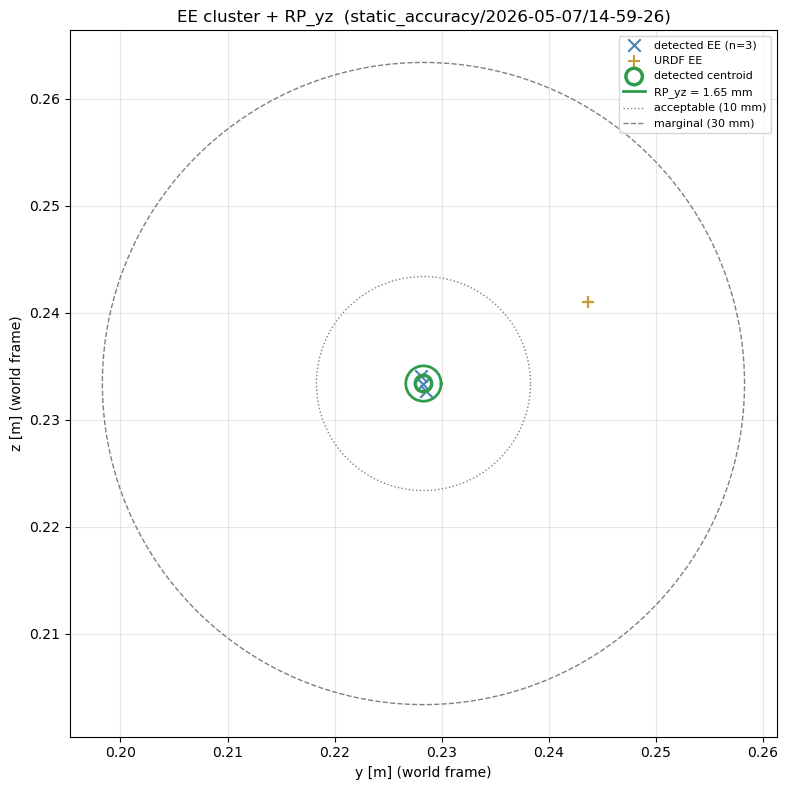

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.scatter(target['det_ee_y'], target['det_ee_z'], marker='x', s=80, c='steelblue',
           label=f'detected EE (n={len(target)})', zorder=4)
# URDF EE origins (where the URDF says the EE marker should be at each visit)
ax.scatter(target['urdf_ee_y'], target['urdf_ee_z'], marker='+', s=80,
           c='#c79a3a', label='URDF EE', zorder=3)

if rep['n'] >= 2:
    cy, cz = rep['centroid']
    ax.scatter([cy], [cz], marker='o', s=140, facecolors='none',
               edgecolors='#2e9c4a', linewidths=2.5,
               label='detected centroid', zorder=5)
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(cy + rep['RP_m'] * np.cos(theta),
            cz + rep['RP_m'] * np.sin(theta),
            color=threshold_color(rep['RP_m'] * 1000),
            linewidth=2, label=f'RP_yz = {rep["RP_m"]*1000:.2f} mm')
    for r_mm, style, lbl in (
        (WEEDING_ACCEPTABLE_MM, ':', f'acceptable ({WEEDING_ACCEPTABLE_MM:.0f} mm)'),
        (WEEDING_MARGINAL_MM, '--', f'marginal ({WEEDING_MARGINAL_MM:.0f} mm)'),
    ):
        r = r_mm / 1000
        ax.plot(cy + r * np.cos(theta), cz + r * np.sin(theta),
                color='gray', linestyle=style, linewidth=1, label=lbl)
elif rep['n'] == 1:
    cy, cz = rep['centroid']
    ax.scatter([cy], [cz], marker='o', s=140, facecolors='none',
               edgecolors='#2e9c4a', linewidths=2.5,
               label='single sample (n=1, no RP_yz)', zorder=5)

ax.set_xlabel('y [m] (world frame)')
ax.set_ylabel('z [m] (world frame)')
ax.set_title(f'EE cluster + RP_yz  ({config["run_id"]})')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='best', fontsize=8)
fig.tight_layout()

## CDF of distance-to-centroid (thesis-quotable: "X% within Y mm")

Cumulative distribution of `d_to_centroid`. Lets you state things like *"95% of samples land within 4.2 mm of the cluster centroid."* Adds the application-threshold lines for context.

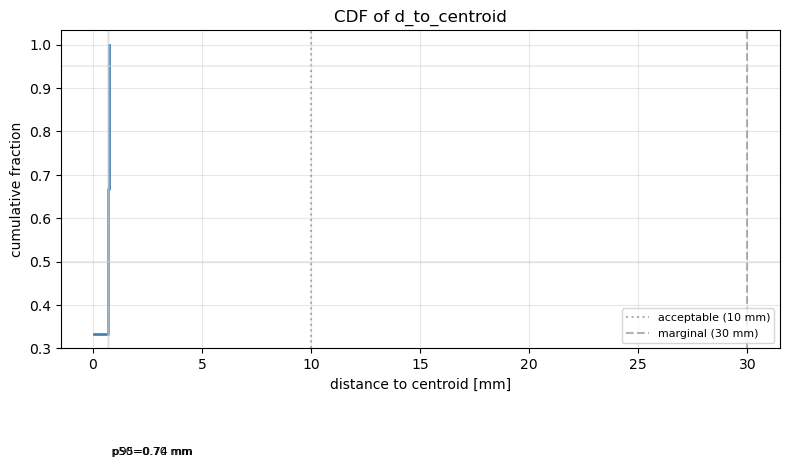

In [6]:
if rep['n'] >= 2:
    d_mm = np.sort(rep['d_to_centroid'].to_numpy() * 1000)
    cdf = np.arange(1, len(d_mm) + 1) / len(d_mm)
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.step(d_mm, cdf, where='post', color='steelblue', linewidth=2)
    ax.axvline(WEEDING_ACCEPTABLE_MM, color='gray', linestyle=':', alpha=0.6,
               label=f'acceptable ({WEEDING_ACCEPTABLE_MM:.0f} mm)')
    ax.axvline(WEEDING_MARGINAL_MM, color='gray', linestyle='--', alpha=0.6,
               label=f'marginal ({WEEDING_MARGINAL_MM:.0f} mm)')
    # Quote-friendly markers at 50/95 percentiles
    p50 = np.percentile(d_mm, 50)
    p95 = np.percentile(d_mm, 95)
    ax.axhline(0.5, color='lightgray', alpha=0.4)
    ax.axhline(0.95, color='lightgray', alpha=0.4)
    ax.axvline(p50, color='lightgray', alpha=0.4)
    ax.axvline(p95, color='lightgray', alpha=0.4)
    ax.text(p50, 0.05, f' p50={p50:.2f} mm', va='bottom', fontsize=8)
    ax.text(p95, 0.05, f' p95={p95:.2f} mm', va='bottom', fontsize=8)
    ax.set_xlabel('distance to centroid [mm]')
    ax.set_ylabel('cumulative fraction')
    ax.set_title('CDF of d_to_centroid')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()
else:
    print('Need ≥ 2 samples for a CDF. Re-run with samples_per_visit ≥ 5.')

## Thesis caveats summary

**Reportable as-is** (clean numbers, no frame caveats):
- `d_error` mean / std / worst / 95% CI from `accuracy_segment_length` — the headline static accuracy number. Frame-independent: scalar Y-Z segment-length comparison cancels any apriltag-vs-URDF axis convention difference.
- `RP_yz` (ISO 9283 Pose Repeatability) on the detected cluster — frame-independent.

**Tunable thresholds**:
- Application zones (`acceptable`, `marginal`, `failing`) live in `analysis/metrics.py` and currently target weeding (1 cm typical, 3 cm marginal). Re-tune for the actuator head you use.

**Re-run for thesis-quality stats**:
- `iterations >= 10` so the histogram is meaningful and the 95% CI tightens. With one sample per visit, total sample count equals iteration count.